### A2 — Cost Map

  [cache] Loading costmap_A2_1_50m.gpkg from disk (use force_rebuild=True to rebuild)
  [cache] Loading costmap_A2_2_50m.gpkg from disk (use force_rebuild=True to rebuild)


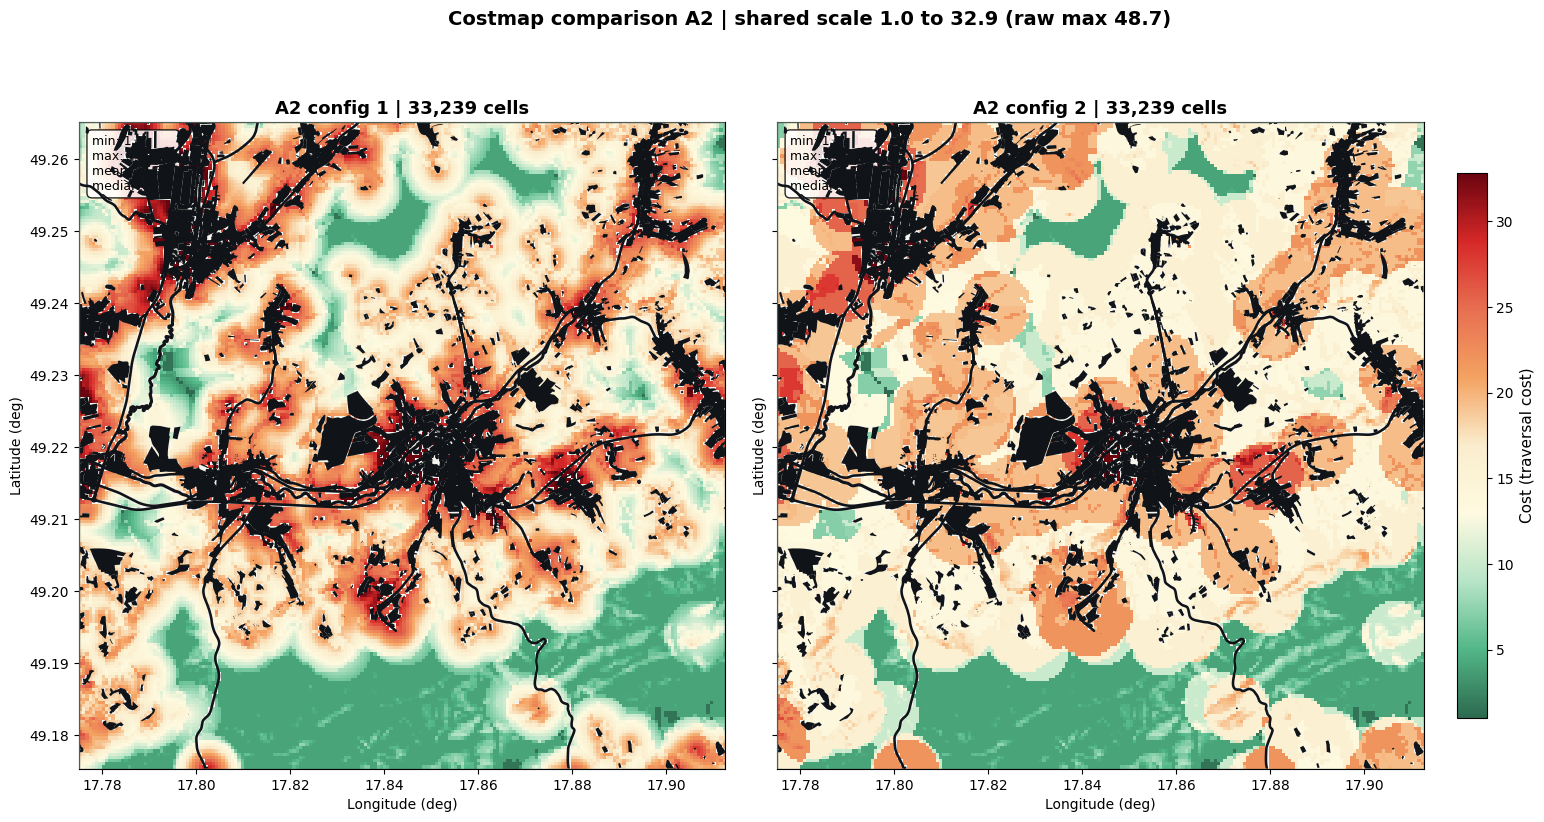

In [ ]:
"""
Build and compare two square costmaps for A2.
Each scenario uses its own config module and both outputs share one color scale.
"""

import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

from src.costmap_builder import build_costmaps_for_scenarios
from src.map_plot import plot_costmaps_side_by_side

AREA_LABEL = "A2"
GEOJSON_PATH = Path("../data_A2.geojson")
GPKG_PATH = Path("../data/raw/ZABAGED_RESULTS.gpkg")
OUTPUT_DIR = Path("../data/processed/A2")
CELL_SIZE = 50

SCENARIOS = [
    {"module": "config_costs_A2_1", "label": "A2 config 1", "export_prefix": "costmap_A2_1"},
    {"module": "config_costs_A2_2", "label": "A2 config 2", "export_prefix": "costmap_A2_2"},
]

scenario_results = build_costmaps_for_scenarios(
    SCENARIOS,
    GEOJSON_PATH,
    GPKG_PATH,
    OUTPUT_DIR,
    CELL_SIZE,
    # force_rebuild=True,
)
plot_costmaps_side_by_side(scenario_results, AREA_LABEL)



DIJKSTRA A2 config 1
Start coord: (17.79, 49.18) -> square cell_id=1981
Goal  coord: (17.9, 49.24) -> square cell_id=24324
Start and Goal are outside exclusion zones.
  [A2 config 1] Building graph (33,239 nodes)... 122,827 direct + 28,937 jump edges (1,151 blocked by can_cross) (3.3 s)
  [A2 config 1] Turn penalty active: 9 dirs x 21 jumps = 6,282,171 states (~102 MB)
  [A2 config 1] Running Dijkstra (6,282,171 states)... 3,476,091 expansions (57.6 s)
Total cost: 2365.7 | 257 cells | ~15,041 m | jumps: 1x | turns: 12 | 61.09 s total

DIJKSTRA A2 config 2
Start coord: (17.79, 49.18) -> square cell_id=1981
Goal  coord: (17.9, 49.24) -> square cell_id=24324
Start and Goal are outside exclusion zones.
  [A2 config 2] Building graph (33,239 nodes)... 122,827 direct + 28,937 jump edges (1,151 blocked by can_cross) (3.3 s)
  [A2 config 2] Turn penalty active: 9 dirs x 21 jumps = 6,282,171 states (~102 MB)
  [A2 config 2] Running Dijkstra (6,282,171 states)... 3,500,821 expansions (59.3 s)
T

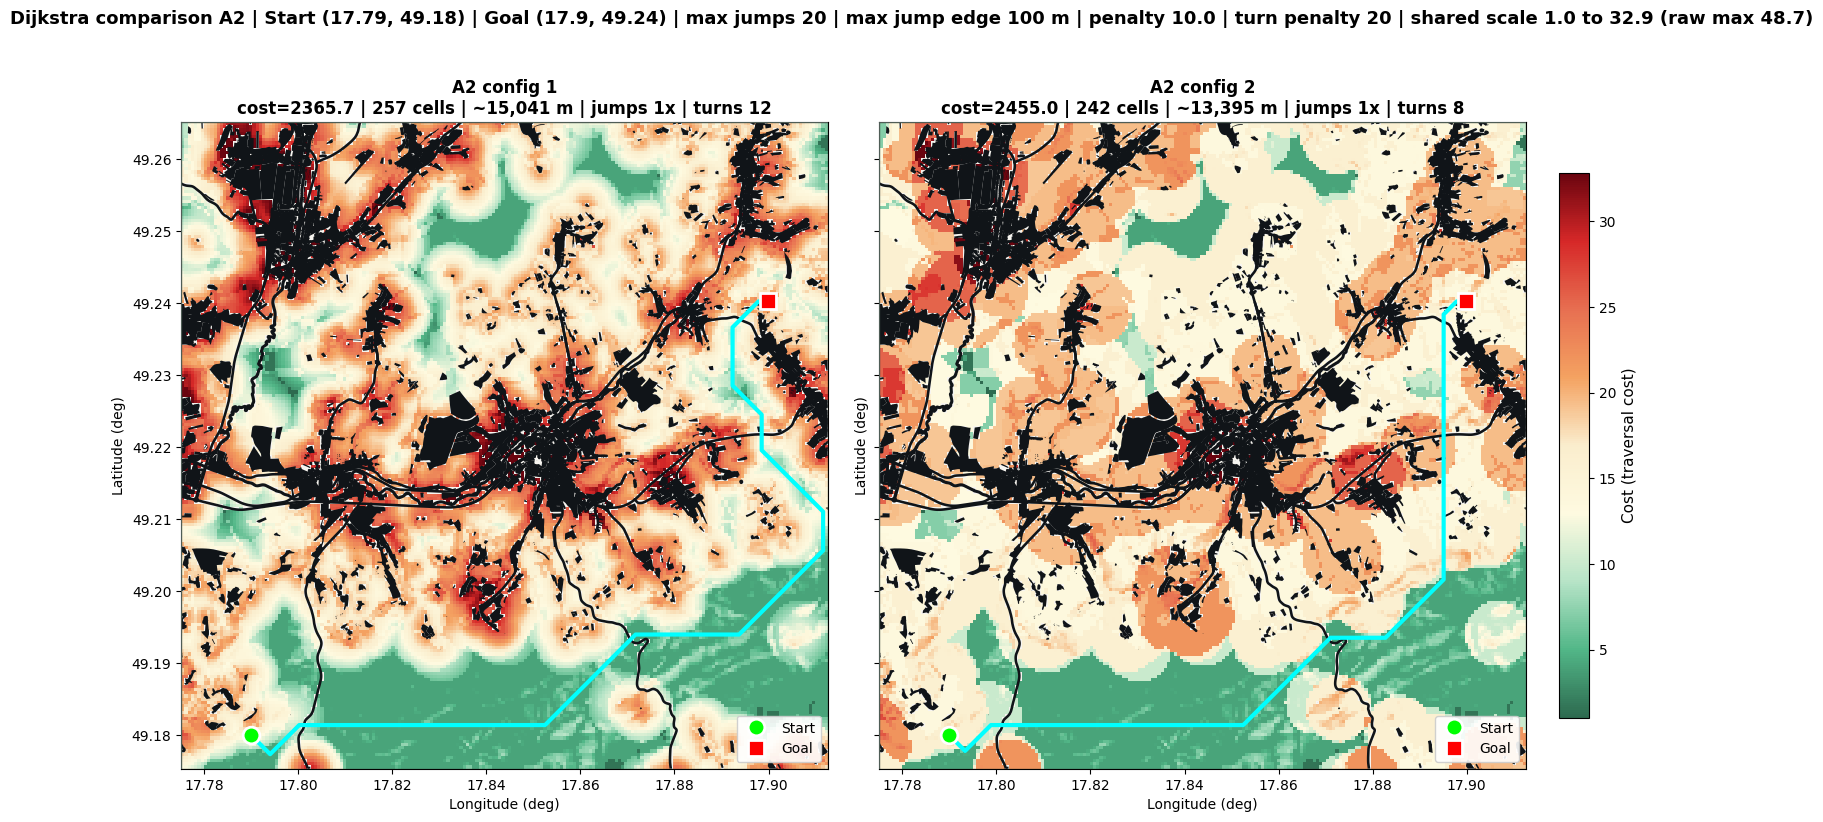

In [2]:
"""
Run and compare Dijkstra on both A2 costmaps.
Both scenarios use the same start/goal and shared visualization scaling.
"""

from src.dijkstra import run_dijkstra_for_scenarios
from src.map_plot import plot_dijkstra_side_by_side

START_LONLAT = (17.79, 49.18)
GOAL_LONLAT = (17.90, 49.24)

EXCLUSION_PENALTY = 10.0
MAX_JUMPS = 20
MAX_JUMP_EDGE_M = 100.0
TURN_PENALTY = 20

route_results = run_dijkstra_for_scenarios(
    scenario_results,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)

plot_dijkstra_side_by_side(
    route_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)


In [3]:
"""
PPO block - inference on the 50 m costmap with forced coarse steps.
Each action moves ~300 m (virtual 8-directional coarse grid) to reduce zigzagging.
Uses route_results from block 3 (same start/goal, same 50 m costmap).
"""
import importlib
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

import ppo_routing_cnn
import src.ppo_inference as ppo_inference

importlib.reload(ppo_inference)

AREA_LABEL = globals().get("AREA_LABEL", "A2")
EXCLUSION_PENALTY = globals().get("EXCLUSION_PENALTY", 10)
MAX_JUMPS = globals().get("MAX_JUMPS", 10)
TURN_PENALTY = globals().get("TURN_PENALTY", 1.0)

MODEL_PATH = Path("../ppo_models/coarse300_12km_v4/ppo_routing_final")
PPO_SAMPLE_COUNT = 2
PPO_MAX_ATTEMPTS = 50
PPO_MAX_STEPS = 120
COARSE_STEP_M = 300

ppo_sample_results = ppo_inference.run_ppo_samples_for_scenarios(
    route_results,
    model_path=MODEL_PATH,
    n_samples=PPO_SAMPLE_COUNT,
    max_attempts=PPO_MAX_ATTEMPTS,
    exclusion_penalty=EXCLUSION_PENALTY,
    max_jumps=MAX_JUMPS,
    turn_penalty=TURN_PENALTY,
    max_steps=PPO_MAX_STEPS,
    coarse_step_m=COARSE_STEP_M,
)


  [A2 config 1] Building coarse graph (300 m steps)...
  Coarse graph (300 m): 32781/33239 nodes reachable, avg 6.2 directions/node
  Detected torch.compile() artifact - remapping _orig_mod keys...
  [A2 config 1 attempt 1] PPO: FAILED to reach goal in 120 steps (1.16s)
  [A2 config 1 attempt 2] PPO: FAILED to reach goal in 42 steps (0.22s)
  [A2 config 1 attempt 3] PPO: FAILED to reach goal in 120 steps (0.69s)
  [A2 config 1 attempt 4] PPO: FAILED to reach goal in 56 steps (0.33s)
  [A2 config 1 attempt 5] PPO: FAILED to reach goal in 120 steps (0.70s)
  [A2 config 1 attempt 6] PPO: FAILED to reach goal in 120 steps (0.65s)
  [A2 config 1 attempt 7] PPO: cost=2115.4 | 116 cells | ~35,191 m | jumps=0 | turns=88 | steps=115 | 0.63s
  [A2 config 1 attempt 8] PPO: FAILED to reach goal in 120 steps (0.66s)
  [A2 config 1 attempt 9] PPO: FAILED to reach goal in 120 steps (0.70s)
  [A2 config 1 attempt 10] PPO: FAILED to reach goal in 120 steps (0.59s)
  [A2 config 1 attempt 11] PPO: FAILED

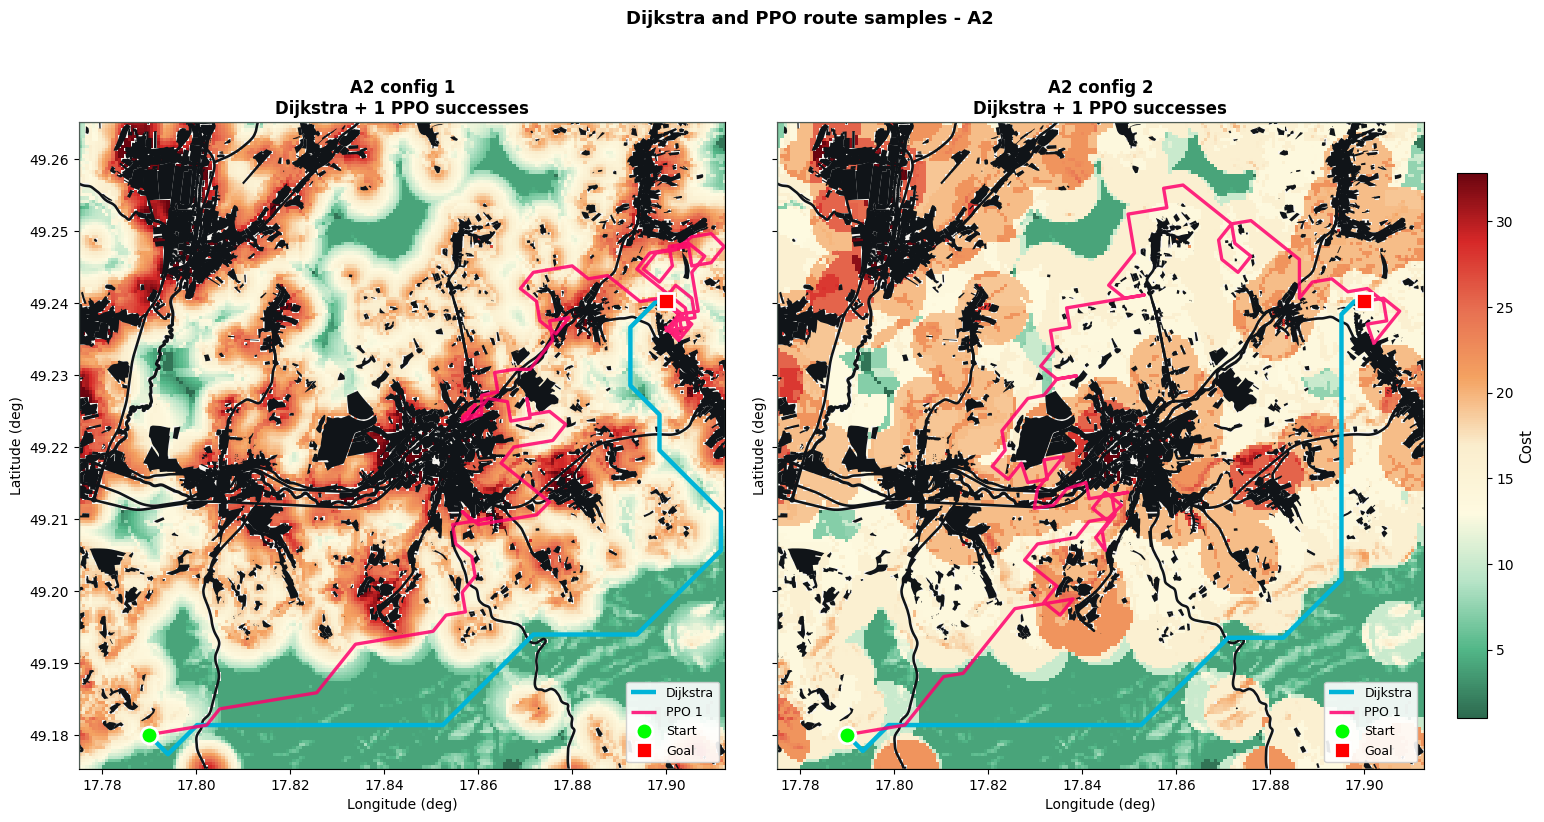

In [4]:
import src.ppo_visualization as ppo_visualization

ppo_visualization.plot_dijkstra_with_ppo_samples(
    ppo_sample_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
)
